# import library

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

# merge data

In [ ]:
data_path = '/home/agung/Documents/alcr/ABC2026 Sozolab Challenge-20260110T085845Z-1-001/ABC2026 Sozolab Challenge/Dataset/BLE Data'

file_name = '4 day'

rssi_list = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16', '17','18','19','20', '21','22', '23','24','25']

mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

file_list = os.listdir(data_path)

csv_data = []
for csv_file in file_list:
  csv_data.append(pd.read_csv(os.path.join(data_path,csv_file),names=['user_id','timestamp','name', 'mac address', 'RSSI', 'power']))

df = csv_data[0]
for i in range(1,len(csv_data)):
  df = pd.concat([df,csv_data[i]])

print(df.shape)
df.head(5)

In [ ]:
# df.to_csv('df_concatenated.csv', index=False)

# load data

In [ ]:
df = pd.read_csv('../../dataset/df_concatenated.csv')
label = pd.read_csv('../../dataset/Dataset/5f_label_loc_train.csv')

# eda

In [ ]:
print(df.info())

print(label.info())

## rssi

In [ ]:
df.head(1)

In [ ]:
print(df['user_id'].value_counts())
print(df['name'].value_counts())

In [ ]:
print(df['mac address'].nunique())
print(df['power'].nunique())
print(df['RSSI'].nunique())

In [ ]:
plt.hist(df['power'])

In [ ]:
plt.hist(df['RSSI'])

## label

In [ ]:
label.head(1)

In [ ]:
print(label['activity'].value_counts())
print(label['user_id'].value_counts())
print(label['user'].value_counts())
print(label['room'].value_counts())
print(label['floor'].value_counts())

# preprocessing

## cleaning

In [ ]:
df = df.drop(columns=['name'])

label = label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'user', 'floor'])

In [ ]:
# rename agar jelas
label = label.rename(columns={
    'started_at': 'start_time',
    'finished_at': 'stop_time'
})

# parse waktu
label['start_time'] = pd.to_datetime(label['start_time'], errors='coerce')
label['stop_time']  = pd.to_datetime(label['stop_time'], errors='coerce')

# hitung durasi
label['duration'] = (label['stop_time'] - label['start_time']).dt.total_seconds()

# filter valid
label = label[
    label['start_time'].notna() &
    label['stop_time'].notna() &
    (label['duration'] > 0) &
    label['deleted_at'].isna()
]

# hapus null penting & duplikat
label = label.dropna(subset=['room'])
label = label.drop_duplicates()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]

In [ ]:
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Tokyo')
label['start_time'] = label['start_time'].dt.tz_convert('Asia/Tokyo')
label['stop_time'] = label['stop_time'].dt.tz_convert('Asia/Tokyo')

In [ ]:
label = label.loc[label['activity'] == 'Location']
label = label.drop(columns=['deleted_at', 'updated_at', 'activity'])

In [ ]:
df = df.sort_values('timestamp').reset_index(drop=True)
label = label.sort_values('start_time').reset_index(drop=True)

In [ ]:
# ambil rentang label
start_label = label['start_time'].min()
end_label = label['stop_time'].max()

# potong RSSI ke rentang label
df = df[(df['timestamp'] >= start_label) & (df['timestamp'] <= end_label)].copy()

print(df['timestamp'].min(), df['timestamp'].max())

In [ ]:
print(start_label)
print(end_label)

In [ ]:
rooms = []
lbl = label.to_dict('records')
j = 0
n = len(lbl)

for ts in df['timestamp']:
    # geser interval label sampai stop_time >= ts
    while j < n and ts > lbl[j]['stop_time']:
        j += 1

    if j < n and lbl[j]['start_time'] <= ts <= lbl[j]['stop_time']:
        rooms.append(lbl[j]['room'])
    else:
        rooms.append(np.nan)

df['room'] = rooms

# buang RSSI tanpa label
df1 = df.dropna(subset=['room']).reset_index(drop=True)


In [ ]:
print(df1.shape)
print(df1['room'].value_counts())

In [ ]:
df1.info()

In [ ]:
df1.to_csv('../../dataset/df_cleaned.csv')

## feature engineering

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [2]:
df = pd.read_csv('../../dataset/df_cleaned.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]
df = df.drop(columns=['Unnamed: 0'])

In [4]:
mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

df = df[df['mac address'].isin(mac_list)]
df = df.sort_values('timestamp').reset_index(drop=True)

In [5]:
WINDOW = '45s'
df['window_start'] = df['timestamp'].dt.floor(WINDOW)

room_per_window = (
    df.groupby('window_start')['room']
      .nunique()
      .value_counts()
)

room_per_window

room
1    729
2    175
3     35
4      4
5      1
Name: count, dtype: int64

In [6]:
valid_windows = (
    df.groupby('window_start')['room']
      .nunique()
      .reset_index()
)

valid_windows = valid_windows[valid_windows['room'] == 1]['window_start']

df = df[df['window_start'].isin(valid_windows)].reset_index(drop=True)

df.groupby('window_start')['room'].nunique().value_counts()

room
1    729
Name: count, dtype: int64

In [7]:
# RSSI matrix: window x beacon
rssi_matrix = (
    df
    .groupby(['window_start', 'mac address'])['RSSI']
    .mean()              
    .unstack('mac address')
    .sort_index()
)

In [8]:
agg_funcs = ['mean', 'std', 'var', 'min', 'max', 'median', 'sum', 'count']

feat = (
    df
    .groupby(['window_start', 'room', 'mac address'])['RSSI']
    .agg(agg_funcs)
    .unstack('mac address')
)

# flatten kolom: {mac}_{stat}
feat.columns = [f'{mac}_{stat}' for stat, mac in feat.columns]
feat = feat.reset_index()

In [9]:
feat['hour'] = feat['window_start'].dt.hour
feat['minute'] = feat['window_start'].dt.minute
feat['second'] = feat['window_start'].dt.second

In [10]:
feat = feat.fillna(0)

In [11]:
feat.columns.tolist()

['window_start',
 'room',
 'C6:CD:5E:3D:2F:BB_mean',
 'C8:5B:BF:37:07:A0_mean',
 'C9:17:55:E2:3E:0E_mean',
 'C9:EA:57:8B:0F:80_mean',
 'CA:60:AB:EE:EC:7F_mean',
 'CC:54:33:F6:A7:90_mean',
 'D4:33:FD:F4:C2:A8_mean',
 'D6:51:7F:AB:0E:29_mean',
 'D6:7C:1D:2C:2A:0A_mean',
 'D6:F4:3A:79:74:63_mean',
 'D7:26:F6:A3:44:D2_mean',
 'DA:E1:70:5F:44:97_mean',
 'DC:22:B8:17:4E:B5_mean',
 'DD:10:10:F6:4F:27_mean',
 'DD:83:B0:27:FD:36_mean',
 'E5:CD:4A:36:87:06_mean',
 'E6:60:05:1F:88:F9_mean',
 'E6:99:D1:EC:C6:81_mean',
 'E6:F3:93:A8:9E:22_mean',
 'EA:09:20:80:D6:44_mean',
 'EA:66:A1:12:2C:F4_mean',
 'EB:20:56:87:04:5A_mean',
 'EE:E7:46:DC:19:6F_mean',
 'F6:DA:97:C7:D5:28_mean',
 'F7:7F:78:76:7E:F3_mean',
 'C6:CD:5E:3D:2F:BB_std',
 'C8:5B:BF:37:07:A0_std',
 'C9:17:55:E2:3E:0E_std',
 'C9:EA:57:8B:0F:80_std',
 'CA:60:AB:EE:EC:7F_std',
 'CC:54:33:F6:A7:90_std',
 'D4:33:FD:F4:C2:A8_std',
 'D6:51:7F:AB:0E:29_std',
 'D6:7C:1D:2C:2A:0A_std',
 'D6:F4:3A:79:74:63_std',
 'D7:26:F6:A3:44:D2_std',
 'DA:E1:70:5F

# modelling

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [13]:
X = feat.drop(columns=['window_start', 'room'])
y = feat['room']

In [14]:
X.columns = (
    X.columns
    .str.replace(':', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [15]:
X.columns.tolist()

['C6_CD_5E_3D_2F_BB_mean',
 'C8_5B_BF_37_07_A0_mean',
 'C9_17_55_E2_3E_0E_mean',
 'C9_EA_57_8B_0F_80_mean',
 'CA_60_AB_EE_EC_7F_mean',
 'CC_54_33_F6_A7_90_mean',
 'D4_33_FD_F4_C2_A8_mean',
 'D6_51_7F_AB_0E_29_mean',
 'D6_7C_1D_2C_2A_0A_mean',
 'D6_F4_3A_79_74_63_mean',
 'D7_26_F6_A3_44_D2_mean',
 'DA_E1_70_5F_44_97_mean',
 'DC_22_B8_17_4E_B5_mean',
 'DD_10_10_F6_4F_27_mean',
 'DD_83_B0_27_FD_36_mean',
 'E5_CD_4A_36_87_06_mean',
 'E6_60_05_1F_88_F9_mean',
 'E6_99_D1_EC_C6_81_mean',
 'E6_F3_93_A8_9E_22_mean',
 'EA_09_20_80_D6_44_mean',
 'EA_66_A1_12_2C_F4_mean',
 'EB_20_56_87_04_5A_mean',
 'EE_E7_46_DC_19_6F_mean',
 'F6_DA_97_C7_D5_28_mean',
 'F7_7F_78_76_7E_F3_mean',
 'C6_CD_5E_3D_2F_BB_std',
 'C8_5B_BF_37_07_A0_std',
 'C9_17_55_E2_3E_0E_std',
 'C9_EA_57_8B_0F_80_std',
 'CA_60_AB_EE_EC_7F_std',
 'CC_54_33_F6_A7_90_std',
 'D4_33_FD_F4_C2_A8_std',
 'D6_51_7F_AB_0E_29_std',
 'D6_7C_1D_2C_2A_0A_std',
 'D6_F4_3A_79_74_63_std',
 'D7_26_F6_A3_44_D2_std',
 'DA_E1_70_5F_44_97_std',
 'DC_22_B8_17

In [16]:
min_samples = 2
valid_rooms = y.value_counts()[y.value_counts() >= min_samples].index

mask = y.isin(valid_rooms)
X = X[mask]
y = y[mask]

In [31]:
print(X.shape, y.shape)
X.iloc[:2, :5]
y.value_counts()

(728, 203) (728,)


room
nurse station    146
kitchen          127
Office Small      82
cafeteria         67
Cafeteria D       61
Office Large      39
hallway           31
523               31
201               17
513               16
213               13
520               12
512               11
208               11
210               10
522                9
Cafeteria B        8
cleaning           7
511                5
515                5
501                4
508                3
202                3
503                3
Bathroom           3
510                2
Clean Room         2
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

## GCN Modeling for Multiclass Classification

In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Number of classes
num_classes = len(np.unique(y_enc))
print(f"Number of classes: {num_classes}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Using device: cuda
Number of classes: 27
X_train shape: (509, 204), X_test shape: (219, 204)


In [73]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

X_train_tensor shape: torch.Size([509, 204])
y_train_tensor shape: torch.Size([509])


In [74]:
# Create graph structure using k-NN
from sklearn.neighbors import kneighbors_graph

k = 5  # Number of neighbors
# Build adjacency matrix
adj_train = kneighbors_graph(X_train, n_neighbors=k, mode='connectivity', include_self=True)
adj_train = adj_train.toarray()

# Convert to edge_index format
edge_index = []
for i in range(adj_train.shape[0]):
    for j in range(adj_train.shape[1]):
        if adj_train[i, j] > 0:
            edge_index.append([i, j])

edge_index = torch.LongTensor(edge_index).t().contiguous().to(device)
print(f"Edge index shape: {edge_index.shape}")

# Create training data
train_data = Data(x=X_train_tensor, edge_index=edge_index, y=y_train_tensor)
print(f"Training graph created with {train_data.num_nodes} nodes and {train_data.num_edges} edges")

Edge index shape: torch.Size([2, 2545])
Training graph created with 509 nodes and 2545 edges


/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [75]:
# Define GCN Model
class GCNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNConv(input_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.gcn3 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout
        
    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.gcn2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.gcn3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Initialize model
input_dim = X_train_tensor.shape[1]
hidden_dim = 64
output_dim = num_classes

model = GCNModel(input_dim, hidden_dim, output_dim, dropout=0.5).to(device)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

GCNModel(
  (gcn1): GCNConv(204, 64)
  (gcn2): GCNConv(64, 64)
  (gcn3): GCNConv(64, 27)
)
Total parameters: 19035


In [76]:
# Training settings
from sklearn.metrics import f1_score

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
criterion = nn.NLLLoss()
epochs = 10000
patience = 30
best_loss = float('inf')
patience_counter = 0

# Training history
train_losses = []
val_losses = []

print("Starting training...")

Starting training...


In [77]:
# Training loop
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(train_data.x, train_data.edge_index)
    
    # Compute loss
    loss = criterion(out, train_data.y)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Evaluate on training set
    model.eval()
    with torch.no_grad():
        train_out = model(train_data.x, train_data.edge_index)
        train_loss = criterion(train_out, train_data.y)
        train_logits_epoch = train_out.argmax(dim=1).cpu().numpy()
        train_accuracy_epoch = (train_logits_epoch == y_train).mean()
        train_f1_macro_epoch = f1_score(y_train, train_logits_epoch, average='macro', zero_division=0)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Loss: {train_loss.item():.4f} | Accuracy: {train_accuracy_epoch:.4f} | F1 Macro: {train_f1_macro_epoch:.4f}")
    
    # Early stopping
    if train_loss.item() < best_loss:
        best_loss = train_loss.item()
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        model.load_state_dict(best_model_state)
        break

print("Training completed!")

Epoch 20/10000 | Loss: 5889.6216 | Accuracy: 0.0177 | F1 Macro: 0.0064
Epoch 40/10000 | Loss: 4125.6421 | Accuracy: 0.0491 | F1 Macro: 0.0155
Epoch 60/10000 | Loss: 3024.0737 | Accuracy: 0.1159 | F1 Macro: 0.0336
Epoch 80/10000 | Loss: 2505.6501 | Accuracy: 0.2633 | F1 Macro: 0.0605
Epoch 100/10000 | Loss: 2288.3140 | Accuracy: 0.3065 | F1 Macro: 0.0637
Epoch 120/10000 | Loss: 2125.4805 | Accuracy: 0.3281 | F1 Macro: 0.0666
Epoch 140/10000 | Loss: 1973.0853 | Accuracy: 0.3536 | F1 Macro: 0.0700
Epoch 160/10000 | Loss: 1813.7502 | Accuracy: 0.3497 | F1 Macro: 0.0690
Epoch 180/10000 | Loss: 1674.5675 | Accuracy: 0.3556 | F1 Macro: 0.0718
Epoch 200/10000 | Loss: 1539.9149 | Accuracy: 0.3595 | F1 Macro: 0.0739
Epoch 220/10000 | Loss: 1397.8199 | Accuracy: 0.3713 | F1 Macro: 0.0907
Epoch 240/10000 | Loss: 1272.7710 | Accuracy: 0.3792 | F1 Macro: 0.0985
Epoch 260/10000 | Loss: 1170.9462 | Accuracy: 0.3752 | F1 Macro: 0.0979
Epoch 280/10000 | Loss: 1092.3385 | Accuracy: 0.3752 | F1 Macro: 0.0

In [78]:
# Create test graph using the same edge_index from training
# For inference, we use X_train features but test data structure
# Build test data with training graph structure
test_data = Data(x=X_train_tensor, edge_index=edge_index, y=y_train_tensor)

# Predictions on training set
model.eval()
with torch.no_grad():
    train_logits = model(train_data.x, train_data.edge_index)
    train_pred = train_logits.argmax(dim=1).cpu().numpy()
    train_accuracy = (train_pred == y_train).mean()

print(f"Training Accuracy: {train_accuracy:.4f}")

# For test set, we need to create proper predictions
# Method: Use nearest neighbors from training set to get predictions
from sklearn.neighbors import NearestNeighbors

# Find k nearest neighbors in training set for each test sample
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_train)
distances, indices = nbrs.kneighbors(X_test)

# Get predictions based on nearest neighbors from training set
test_pred = np.zeros(len(X_test), dtype=int)
for i, (dist, idx) in enumerate(zip(distances, indices)):
    # Use majority vote from k nearest neighbors
    neighbor_preds = train_pred[idx[1:]]  # Exclude self
    test_pred[i] = np.bincount(neighbor_preds).argmax()

test_accuracy = (test_pred == y_test).mean()
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.2279
Test Accuracy: 0.2283


In [79]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed evaluation metrics
print("\n=== Training Set Metrics ===")
print(classification_report(y_train, train_pred, target_names=le.classes_))

print("\n=== Test Set Metrics ===")
print(classification_report(y_test, test_pred, target_names=le.classes_))

# F1 macro scores
train_f1_macro = f1_score(y_train, train_pred, average='macro')
test_f1_macro = f1_score(y_test, test_pred, average='macro')

print(f"\n=== F1 Macro Scores (Sorted) ===")
metrics_data = [
    {'Dataset': 'Training', 'F1 Macro': train_f1_macro},
    {'Dataset': 'Test', 'F1 Macro': test_f1_macro}
]

# Sort by F1 Macro score in descending order
metrics_df = pd.DataFrame(metrics_data).sort_values('F1 Macro', ascending=False)
print(metrics_df.to_string(index=False))

print(f"\nF1 Macro Score - Training: {train_f1_macro:.4f}")
print(f"F1 Macro Score - Test: {test_f1_macro:.4f}")


=== Training Set Metrics ===
               precision    recall  f1-score   support

          201       0.33      0.08      0.13        12
          202       0.20      0.50      0.29         2
          208       0.00      0.00      0.00         8
          210       0.00      0.00      0.00         7
          213       0.00      0.00      0.00         9
          501       0.00      0.00      0.00         3
          503       0.00      0.00      0.00         2
          508       0.00      0.00      0.00         2
          510       0.00      0.00      0.00         1
          511       0.00      0.00      0.00         3
          512       0.37      0.88      0.52         8
          513       0.00      0.00      0.00        11
          515       0.00      0.00      0.00         4
          520       0.67      0.50      0.57         8
          522       0.00      0.00      0.00         6
          523       0.27      0.18      0.22        22
     Bathroom       0.00      0.00

/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/

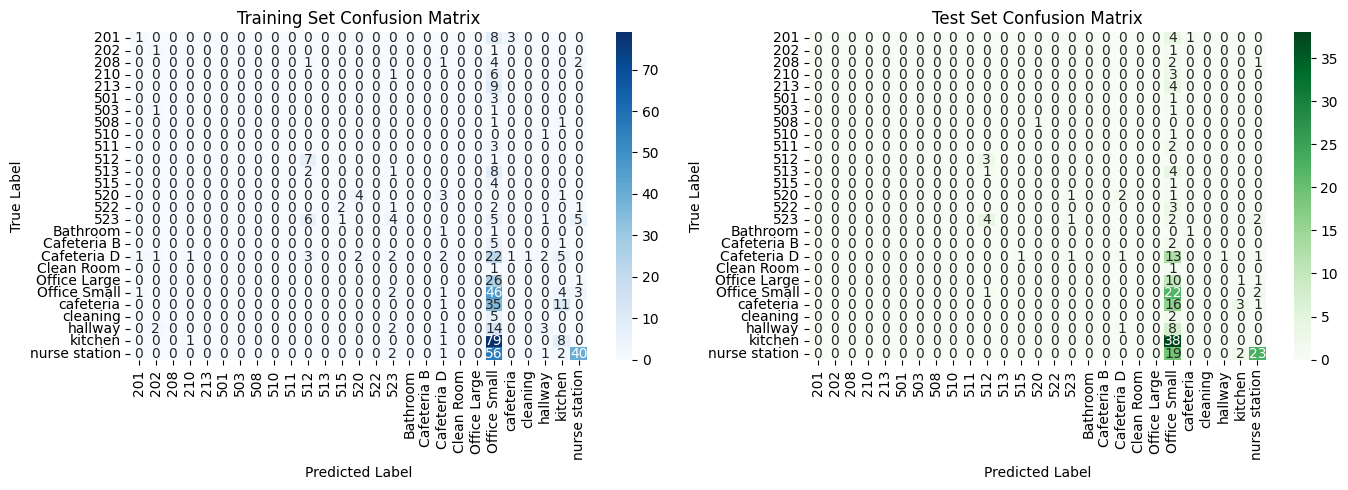

Confusion matrices displayed!


In [80]:
# Confusion Matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set confusion matrix
cm_train = confusion_matrix(y_train, train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Test set confusion matrix
cm_test = confusion_matrix(y_test, test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Test Set Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion matrices displayed!")

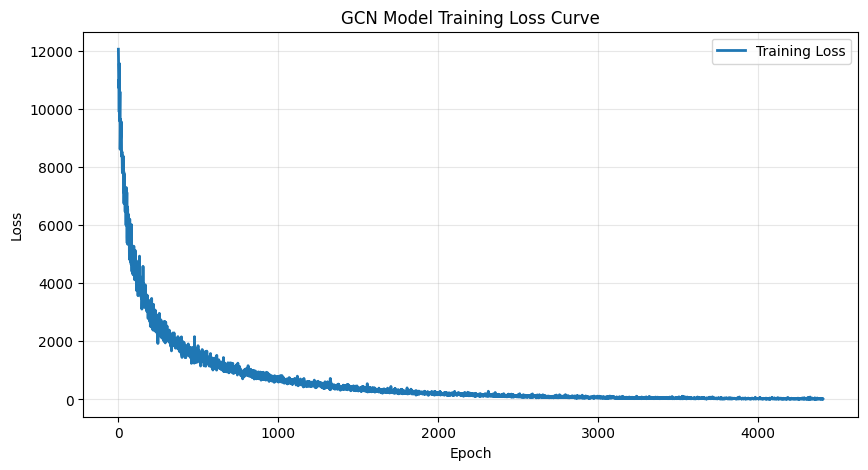

Final Training Loss: 14.2629


In [81]:
# Training loss visualization
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label='Training Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN Model Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")